# ⚡ EnerVision AI — XGBoost Model

**Standalone Notebook**

This notebook trains and evaluates a single machine learning model, **XGBoost**, as part of the **EnerVision AI** household energy-forecasting project.
It is designed to run independently in a fresh Google Colab session.

| | |
|---|---|
| **Project** | EnerVision AI |
| **Model** | XGBoost |
| **Task** | Household energy-consumption forecasting |
| **Dataset** | `HomeC_Cleaned.csv` |
| **Environment** | Google Colab (CPU is sufficient) |

---


## 📦 Step 1: Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## 📂 Step 2: Load Data


In [ ]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/EnerVision_AI/Data/HomecCleaned.csv', low_memory=False)

print(f"✅ Data loaded successfully! Data size: {df.shape}")
display(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data loaded successfully! Data size: (502470, 49)


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,hour_sin,hour_cos,month_sin,month_cos,Net_Energy_lag1,Net_Energy_lag60,Net_Energy_lag1440,Demand_lag1,Demand_lag60,Demand_lag1440
0,2016-01-02 05:00:00,1.819400,0.003400,1.819400,0.114633,0.487533,0.681517,0.051050,0.136367,0.007533,...,0.965926,0.258819,0.5,0.866025,-2.904950,-0.875917,-0.929350,2.908333,0.879450,0.932833
1,2016-01-02 05:01:00,1.795433,0.003367,1.795433,0.114683,0.460867,0.683850,0.050967,0.136383,0.007417,...,0.965926,0.258819,0.5,0.866025,-1.816000,-0.685133,-0.930867,1.819400,0.688583,0.934333
2,2016-01-02 05:02:00,1.768767,0.003383,1.768767,0.114783,0.438900,0.680333,0.051017,0.136067,0.007567,...,0.965926,0.258819,0.5,0.866025,-1.792067,-0.475283,-0.928350,1.795433,0.478733,0.931817
3,2016-01-02 05:03:00,1.450383,0.003383,1.450383,0.114717,0.113017,0.683817,0.050533,0.135983,0.007567,...,0.965926,0.258819,0.5,0.866025,-1.765383,-0.470150,-1.018567,1.768767,0.473583,1.022050
4,2016-01-02 05:04:00,1.363600,0.003333,1.363600,0.114683,0.021700,0.687483,0.050333,0.135817,0.007433,...,0.965926,0.258819,0.5,0.866025,-1.447000,-0.468200,-1.135933,1.450383,0.471617,1.139400


## 🎯 Step 3: Assign X and y


In [ ]:
ignore_cols = [
    # non-numeric / identifier columns
    'time', 'icon', 'summary',

    # the target itself, in every raw/renamed form it appears under
    'use [kW]', 'Demand_kW',

    # solar-generation side: not needed to forecast demand, and keeping
    # the two tasks (demand vs. net-energy) cleanly separated
    'gen [kW]', 'Solar [kW]', 'Solar_kW',

    # belongs to the OTHER (net-energy) task; the real-time status
    # classifier still uses these from the actual data, but they must
    # not be used as model inputs here
    'Net_Energy', 'Net_Energy_Condition',
    'Net_Energy_lag1', 'Net_Energy_lag60', 'Net_Energy_lag1440',

    # superseded by the cyclical (sin/cos) time encodings below
    'hour', 'month', 'dayofweek',
    'House overall [kW]', 'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]',
    'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]', 'Garage door [kW]',
    'Kitchen 12 [kW]', 'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
    'Microwave [kW]', 'Living room [kW]',
]

feature_cols = [col for col in df.columns if col not in ignore_cols]

X = df[feature_cols]
y = df['Demand_kW']  # = 'use [kW]', the household consumption target

print(f"Features ({len(feature_cols)}):", feature_cols)


Features (19): ['temperature', 'humidity', 'visibility', 'apparentTemperature', 'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity', 'dewPoint', 'precipProbability', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Demand_lag1', 'Demand_lag60', 'Demand_lag1440']


## ✂️ Step 4: Time-Based Train/Validation/Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False  # Ensures no temporal data mixing (Time-based split)
)

# Carve a validation slice out of the training data (used for early stopping)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    shuffle=False
)

print(f"✅ X shape: {X.shape}, y shape: {y.shape}")
print(f"✅ Train set shape: {X_tr.shape}, Validation set shape: {X_val.shape}, Test set shape: {X_test.shape}")


✅ X shape: (502470, 19), y shape: (502470,)
✅ Train set shape: (341679, 19), Validation set shape: (60297, 19), Test set shape: (100494, 19)


## ⚙️ Step 5: Preprocessing Pipeline (Impute + Scale)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = feature_cols

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
], remainder='passthrough')


## 🏗️ Step 6: Fit XGBoost Pipeline (Early Stopping picks n_estimators)

Instead of a fixed, guessed number of boosting rounds, we give XGBoost a high ceiling and let `early_stopping_rounds` pick the actual number automatically, based on validation performance.


In [ ]:
from xgboost import XGBRegressor

# Fit the preprocessor on the training slice only (keeps validation/test unseen)
preprocessor.fit(X_tr)
X_tr_prep = preprocessor.transform(X_tr)
X_val_prep = preprocessor.transform(X_val)

xgb_model = XGBRegressor(
    n_estimators=1000,        # high ceiling — early stopping finds the real number
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

xgb_model.fit(
    X_tr_prep, y_tr,
    eval_set=[(X_val_prep, y_val)],
    verbose=10  # print the validation RMSE every 10 boosting rounds (like epoch logs)
)

BEST_N_ESTIMATORS = xgb_model.best_iteration + 1  # best_iteration is 0-indexed
print(f"✅ Early stopping selected n_estimators = {BEST_N_ESTIMATORS}")

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

y_pred = pipeline.predict(X_test)

print("✅ XGBoost pipeline fit complete.")


[0]	validation_0-rmse:0.98491
[10]	validation_0-rmse:0.49121
[20]	validation_0-rmse:0.38943
[30]	validation_0-rmse:0.37564
[40]	validation_0-rmse:0.37656
[50]	validation_0-rmse:0.37670
[53]	validation_0-rmse:0.37819
✅ Early stopping selected n_estimators = 34
✅ XGBoost pipeline fit complete.


## 📊 Step 7: Compare Against Baseline (Cross-Validated)


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor

# a) Simple baseline (Dummy)
baseline_dummy = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

# b) XGBoost candidate model — reuses the n_estimators found via early stopping above
candidate_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=BEST_N_ESTIMATORS,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42
    ))
])

tscv = TimeSeriesSplit(n_splits=3)

models = {
    'Dummy Baseline': baseline_dummy,
    'XGBoost (ML Baseline)': candidate_xgb
}


## 🔄 Step 8: Run Cross-Validation


In [ ]:
cv_results = {}

for name, model_pipeline in models.items():
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=tscv,
        scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error'),
        n_jobs=-1
    )
    cv_results[name] = {
        'MAE': -scores['test_neg_mean_absolute_error'].mean(),
        'RMSE': -scores['test_neg_root_mean_squared_error'].mean()
    }

print("✅ Cross-validation complete.")


✅ Cross-validation complete.


## 📈 Step 9: Display Results


In [ ]:
df_results = pd.DataFrame(cv_results).T
print(df_results)


                            MAE      RMSE
Dummy Baseline         0.646943  1.190871
XGBoost (ML Baseline)  0.193002  0.604220


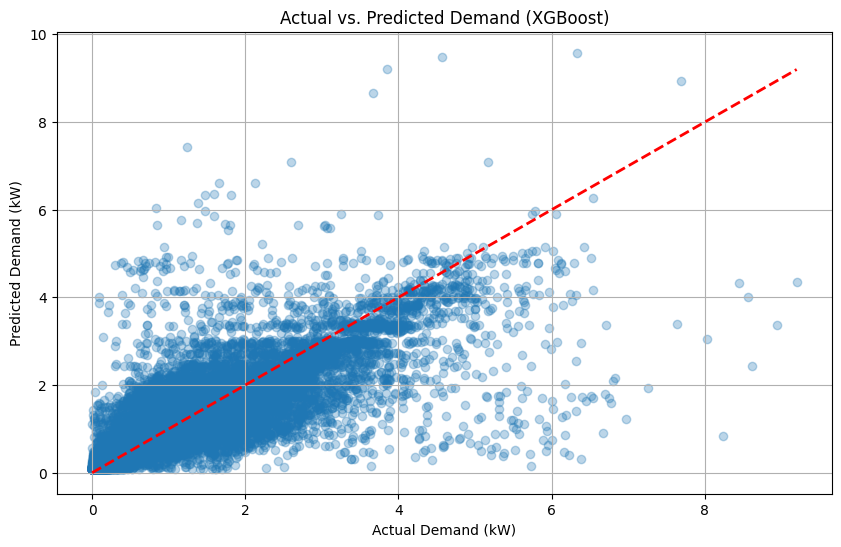

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Demand (kW)')
plt.ylabel('Predicted Demand (kW)')
plt.title('Actual vs. Predicted Demand (XGBoost)')
plt.grid(True)
plt.show()

## 🚀 Step 10: Train Final Model on Full Training Set


In [ ]:
best_xgb_pipeline = candidate_xgb
best_xgb_pipeline.fit(X_train, y_train)

print("✅ Final XGBoost model trained on full training set.")


✅ Final XGBoost model trained on full training set.


## 📊 Step 11: Final Model Evaluation & Comparison Plot



📊 XGBoost Model Performance Evaluation:
• RMSE (Root Mean Squared Error):  0.3163
• MAE (Mean Absolute Error):  0.1343
• R2 Score (Coefficient of Determination):  0.7685



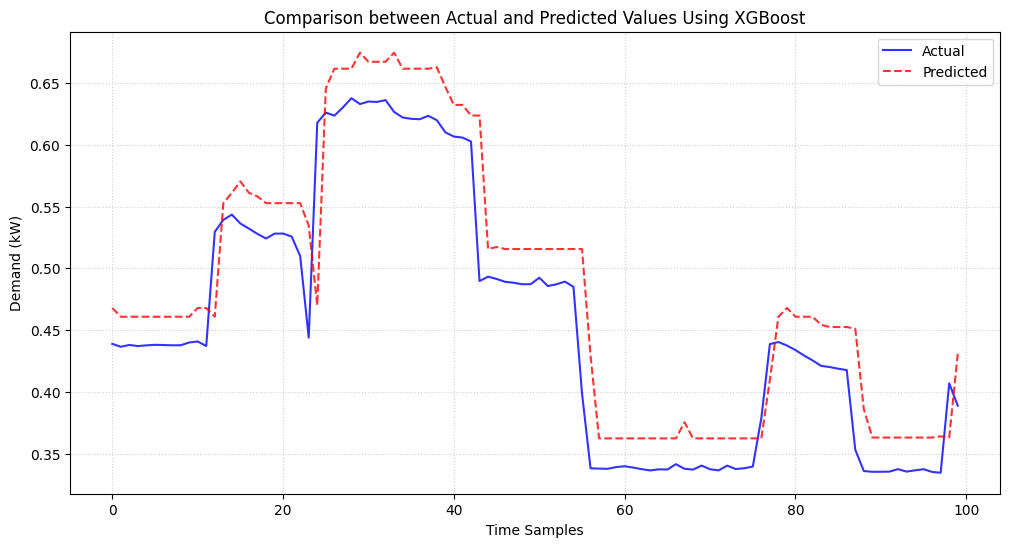

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_final = best_xgb_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred_final)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)

print("\n" + "=" * 30)
print("📊 XGBoost Model Performance Evaluation:")
print(f"• RMSE (Root Mean Squared Error): {rmse: .4f}")
print(f"• MAE (Mean Absolute Error): {mae: .4f}")
print(f"• R2 Score (Coefficient of Determination): {r2: .4f}")
print("=" * 30 + "\n")

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual', color='blue', alpha=0.8)
plt.plot(y_pred_final[:100], label='Predicted', color='red', linestyle='--', alpha=0.8)
plt.title('Comparison between Actual and Predicted Values ​​Using XGBoost')
plt.xlabel('Time Samples')
plt.ylabel('Demand (kW)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 📝 Step 12: Save Metrics for Model Comparison


In [ ]:
import os

RESULTS_PATH = '/content/drive/MyDrive/EnerVision_AI/Models/model_results.csv'

def save_model_result(model_name, mae, rmse, r2=None, path=RESULTS_PATH):
    """Append/update this model's metrics in the shared comparison file."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    row = pd.DataFrame([{'model': model_name, 'mae': mae, 'rmse': rmse, 'r2': r2}])

    if os.path.exists(path):
        existing = pd.read_csv(path)
        existing = existing[existing['model'] != model_name]
        df_out = pd.concat([existing, row], ignore_index=True)
    else:
        df_out = row

    df_out.to_csv(path, index=False)
    print(f"✅ Saved metrics for '{model_name}' to:\n{path}")
    print(df_out)

save_model_result('XGBoost', mae, rmse, r2)


✅ Saved metrics for 'XGBoost' to:
/content/drive/MyDrive/EnerVision_AI/Models/model_results.csv
     model       mae      rmse        r2
0  XGBoost  0.134325  0.316297  0.768521


## 💾 Step 13: Save the Model


In [ ]:
import joblib

model_path = '/content/drive/MyDrive/EnerVision_AI/Models/XGBoost/xgboost_Modele.pkl'
joblib.dump(best_xgb_pipeline, model_path)

print(f"✅ The trained XGBoost model and pipeline have been successfully saved to:\n{model_path}")


✅ The trained XGBoost model and pipeline have been successfully saved to:
/content/drive/MyDrive/EnerVision_AI/Models/XGBoost/xgboost_Modele.pkl
